In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)

In [7]:
# Load the dataset
data = pd.read_csv('../../../data/resample_minmax_all.csv')

# ✅ Extract the ID column (Never modified)
data_id = data["apogee_id"]

# ✅ Extract the Target columns (These are the prediction targets)
data_target = data[["TEFF", "J", "H", "K", "LOGG"]]

# ✅ Define the columns to drop (ID + categorical classifications + unnecessary features)
columns_to_drop = [
    "apogee_id", "TEFF", "J", "H", "K", "LOGG"
]

# Remove unwanted columns
data = data.drop(columns=columns_to_drop)


# Display final dataset structure
print("✅ Data Loaded and Preprocessed Successfully!")
print(f"🆔 ID Columns: {data_id.shape}")
print(f"🎯 Target Columns: {data_target.shape}")

print(data.columns)
# Convert to float32
data = data.astype('float32').reset_index(drop=True)
print("Final Data Shape :", data.shape)


✅ Data Loaded and Preprocessed Successfully!
🆔 ID Columns: (175770,)
🎯 Target Columns: (175770, 5)
Index(['C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE',
       'S_FE', 'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE',
       'FE_H'],
      dtype='object')
Final Data Shape : (175770, 17)


In [8]:
# Convert to PyTorch tensors
full_data_tensor = torch.tensor(data.values, dtype=torch.float32)


In [9]:
class AutoencoderDataset(Dataset):
    def __init__(self, data_tensor):
        self.data_tensor = data_tensor

    def __len__(self):
        return self.data_tensor.size(0)

    def __getitem__(self, idx):
        # For an autoencoder, X=Y (We need to reconstruct the input)
        x = self.data_tensor[idx]
        return x, x

In [10]:
# Split the data into training and validation sets (90/10 here)

# Set the seed for reproducibility
num_samples = len(full_data_tensor)
train_size = int(0.9 * num_samples)
val_size = num_samples - train_size

# Split the data
train_data, val_data = torch.utils.data.random_split(
    full_data_tensor, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

# Create the datasets
train_dataset = AutoencoderDataset(train_data.dataset[train_data.indices])
val_dataset = AutoencoderDataset(val_data.dataset[val_data.indices])

# Create the dataloaders
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)




In [11]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=20, latent_dim=2):
        super(Autoencoder, self).__init__()

        # Encoder : 20 -> 32 -> 64 -> 2
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),                # BatchNorm should improve training
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(64, latent_dim)          # No activation after 2D layer latent space
        )

        # Decoder : 2 -> 64 -> 32 -> 20
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(32, input_dim)           # Output 20D vector
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device :", device)

model = Autoencoder(input_dim=17, latent_dim=2).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Using device : cuda


In [14]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create output directories for latent embeddings and model weights
output_folder = "output_dataset"
os.makedirs(output_folder, exist_ok=True)
weight_folder = "output_weight"
os.makedirs(weight_folder, exist_ok=True)

# Training hyperparameters
num_epochs = 100
patience = 5
criterion = nn.MSELoss()
best_val_loss = float('inf')
epochs_no_improve = 0

# Loop over desired latent dimensions
for latent_dim in [2, 3, 4]:
    print(f"\nTraining autoencoder with latent dimension: {latent_dim}")

    model = Autoencoder(input_dim=17, latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)

        # Validation loop
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, Y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)

        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.6f}  |  Val Loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            model_file = os.path.join(weight_folder, f"best_autoencoder_{latent_dim}D.pth")
            torch.save(model.state_dict(), model_file)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stop!")
                break

    # Load the best model weights
    model_file = os.path.join(weight_folder, f"best_autoencoder_{latent_dim}D.pth")
    model.load_state_dict(torch.load(model_file))
    model.eval()

    # Compute latent embeddings for the full dataset
    with torch.no_grad():
        # Ensure the full dataset is processed on the same device
        full_tensor_device = full_data_tensor.to(device)
        latent_embeddings = model.encoder(full_tensor_device)
    latent_embeddings = latent_embeddings.cpu().numpy()

    # Create a DataFrame for the latent embeddings
    df_latent = pd.DataFrame(latent_embeddings, columns=[f"latent_{i+1}" for i in range(latent_dim)])
    # Add the "apogee_id" column as the first column (assuming data_id is defined)
    df_latent.insert(0, "apogee_id", data_id)

    # Save the latent embeddings to a CSV file
    output_file = os.path.join(output_folder, f"autoencoder_latent_space_{latent_dim}D.csv")
    df_latent.to_csv(output_file, index=False)
    print(f"Latent space {latent_dim}D saved to {output_file}")

Using device: cuda

Training autoencoder with latent dimension: 2
Epoch [1/100]  Train Loss: 0.055322  |  Val Loss: 0.003748
Epoch [2/100]  Train Loss: 0.002860  |  Val Loss: 0.002429
Epoch [3/100]  Train Loss: 0.002228  |  Val Loss: 0.002018
Epoch [4/100]  Train Loss: 0.001930  |  Val Loss: 0.001794
Epoch [5/100]  Train Loss: 0.001770  |  Val Loss: 0.001681


KeyboardInterrupt: 

In [12]:

with torch.no_grad():
    # Re encode the full data
    full_data_gpu = full_data_tensor.to(device)
    latent_2d = model.encoder(full_data_gpu).cpu().numpy()

print("Lattend space shape :", latent_2d.shape)  # Devrait être (175809, 2)
print("Embedding sample:\n", latent_2d[:5])

Lattend space shape : (175770, 4)
Embedding sample:
 [[ 0.23159085  0.49414974 -0.42431438 -0.12852529]
 [ 0.42798647  0.4509272  -0.32467657 -0.22942992]
 [ 0.11478844  0.40205508 -0.455448   -0.08354595]
 [ 0.17341629  0.33924752 -0.4333059  -0.16737118]
 [ 0.36781973  0.45091712 -0.2947725  -0.105262  ]]


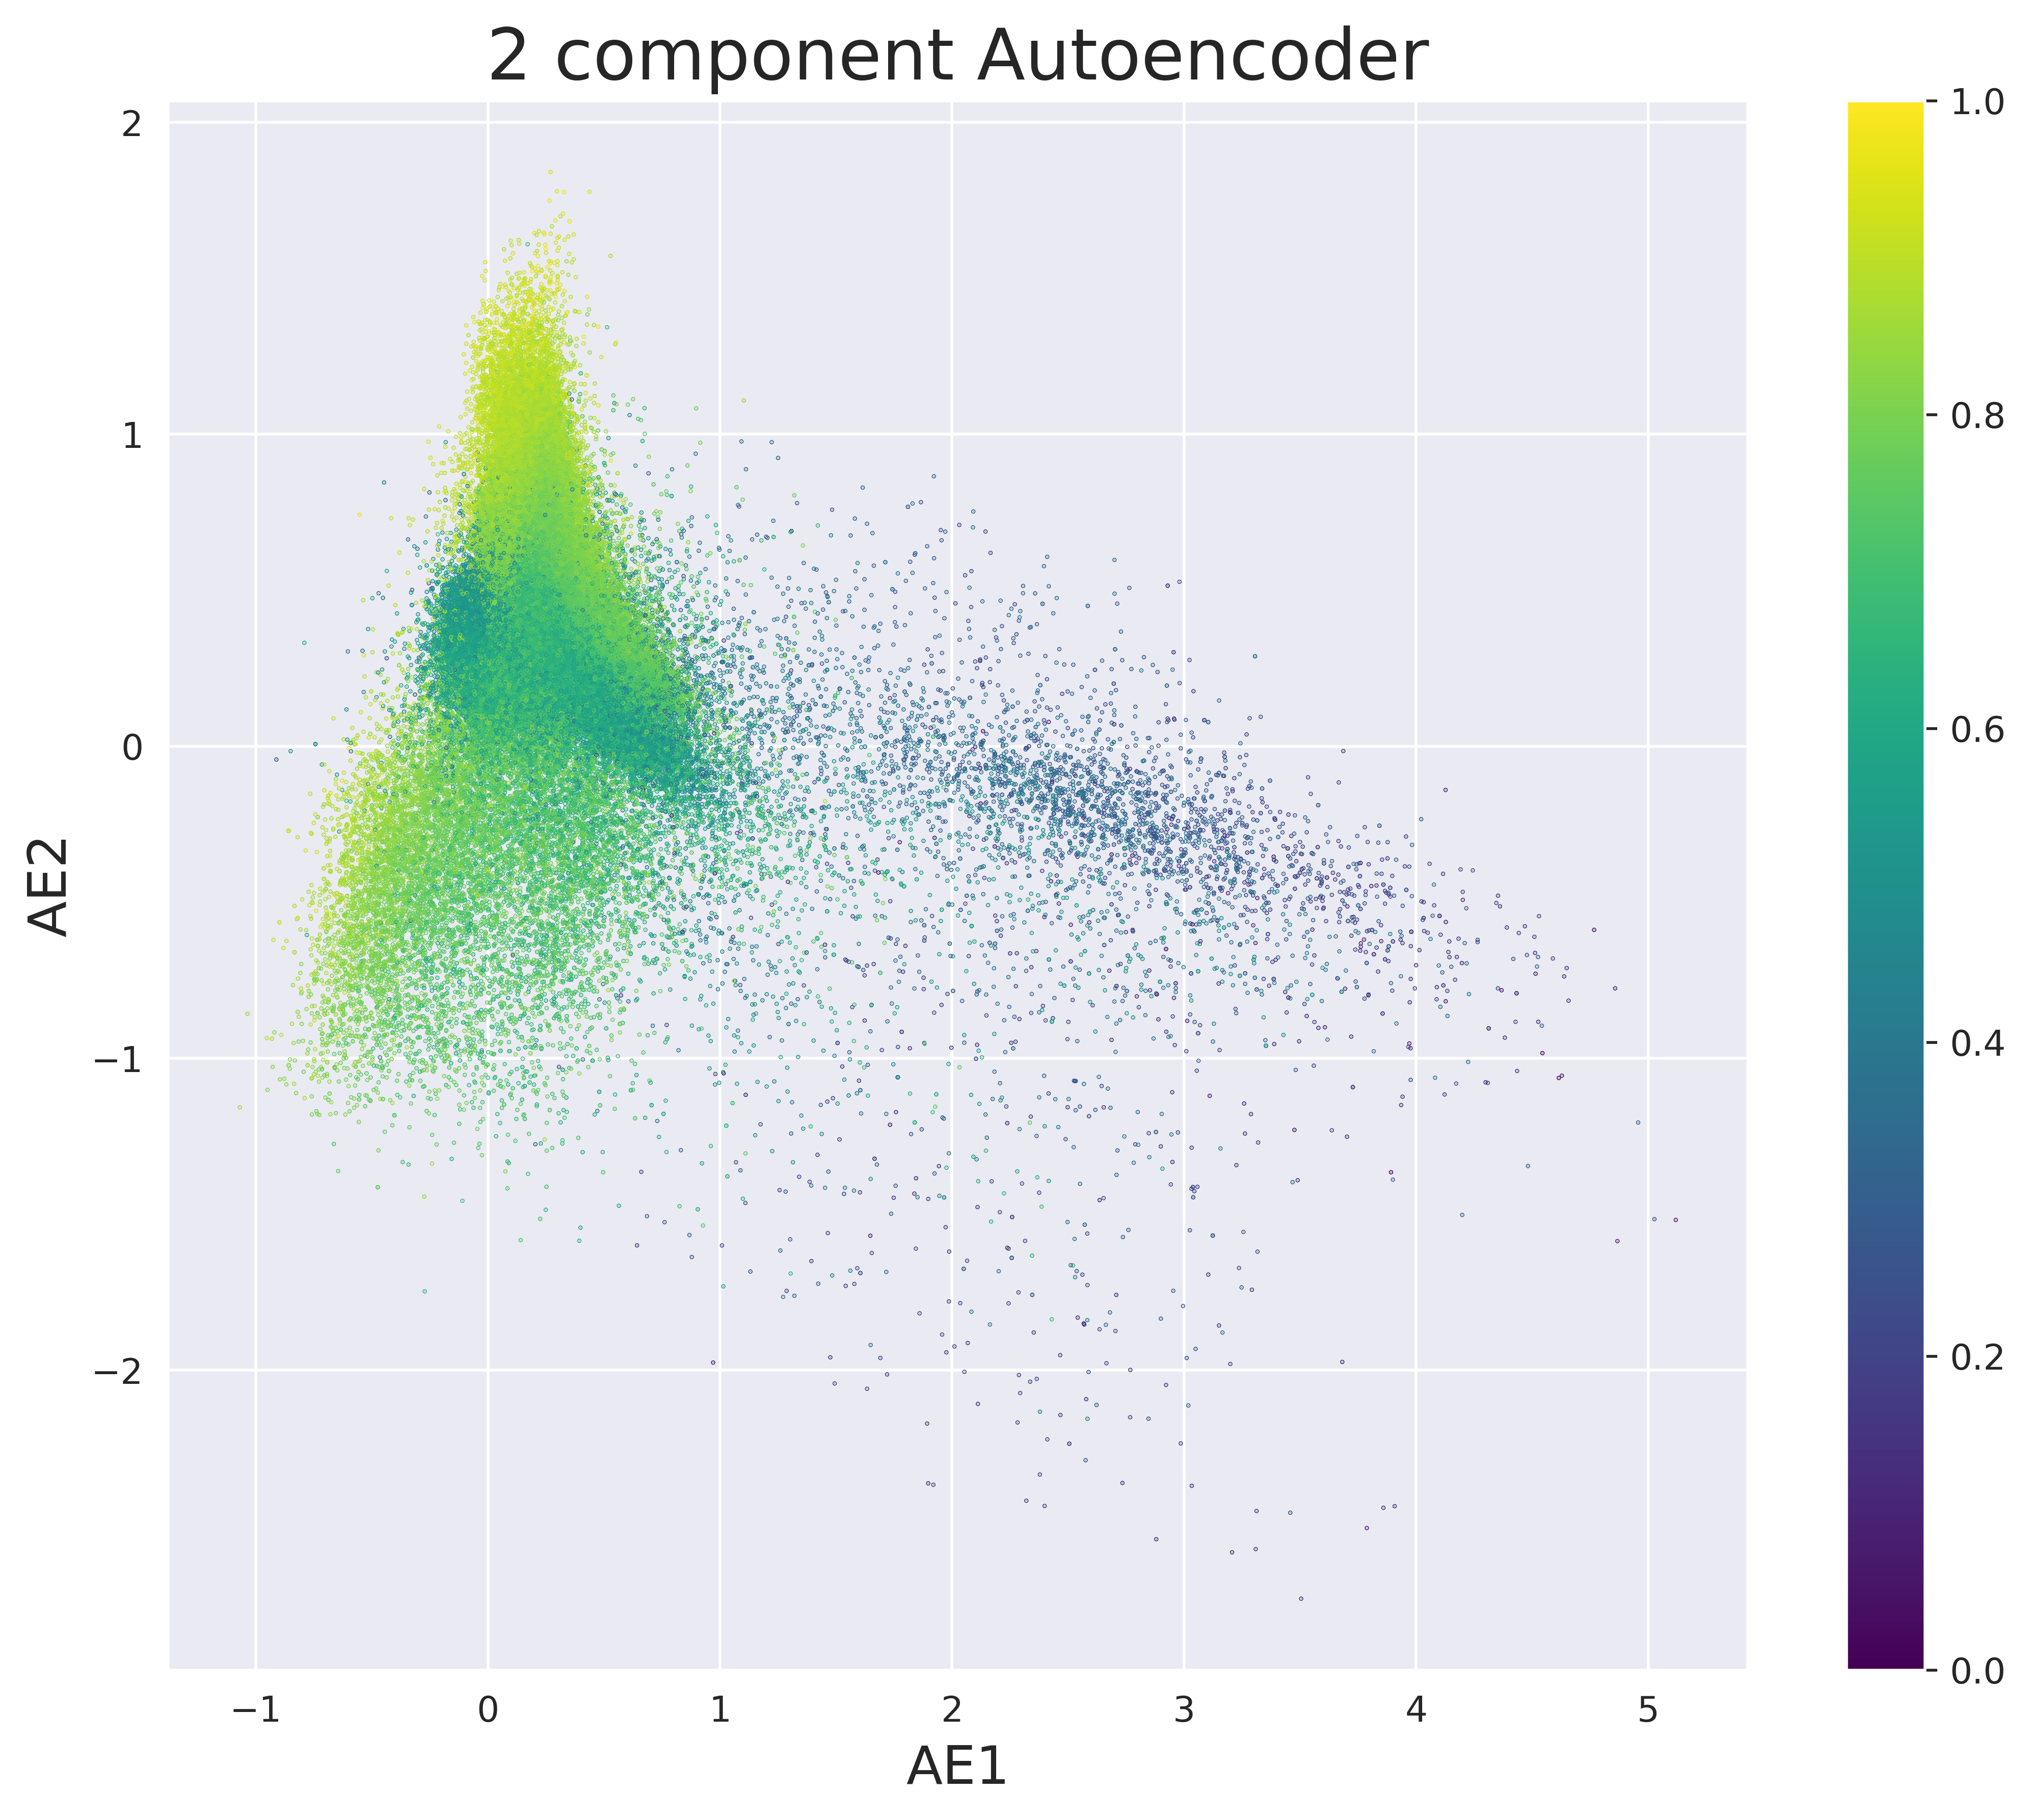

In [13]:
# Plot the Autoencoder result
fig = plt.figure(figsize=(10,8), dpi=500)
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('AE1', fontsize=15)
ax.set_ylabel('AE2', fontsize=15)
ax.set_title('2 component Autoencoder', fontsize=20)
# On utilise latent_2d[:,0] et latent_2d[:,1] pour les coordonnées X et Y respectivement
scatter = ax.scatter(latent_2d[:,0], latent_2d[:,1], c=data['FE_H'], cmap='viridis', s=0.05)
plt.colorbar(scatter)
plt.show()


Étoile choisie: apogee_id=2M00000943+6254542, row_index=5


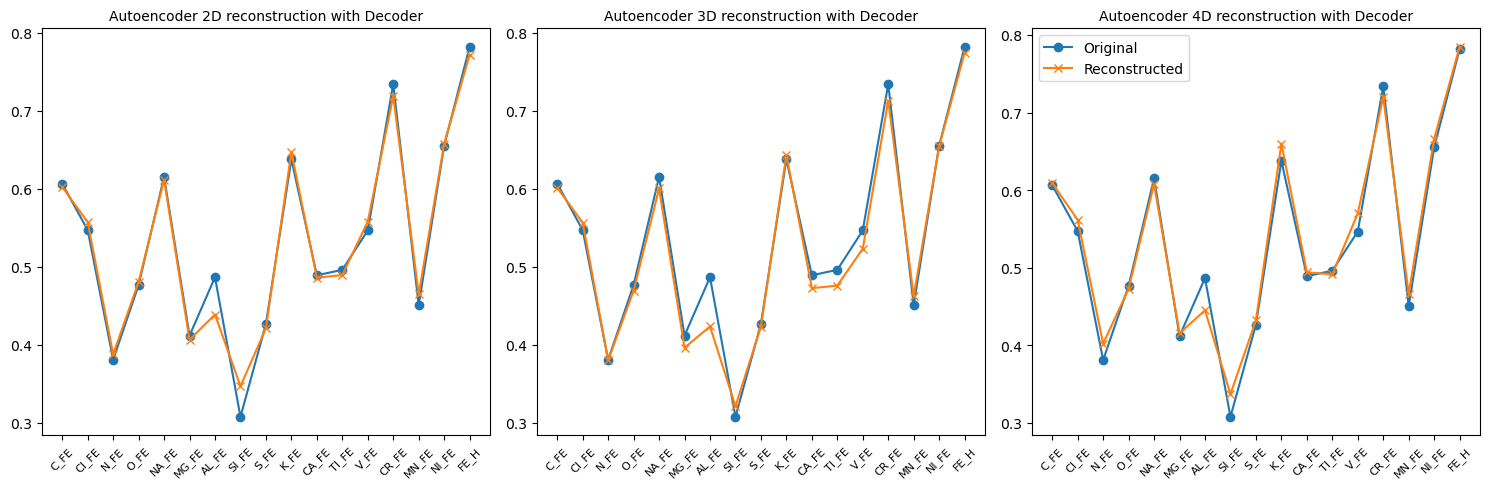

In [16]:
col_names = list(data.columns)  # ex: ['C_FE','CI_FE','N_FE', ...] (17 colonnes)

chosen_id = "2M00000943+6254542"
row_index = data_id[data_id == chosen_id].index
if len(row_index) == 0:
    raise ValueError(f"Impossible de trouver apogee_id='{chosen_id}' dans data_id.")
row_index = row_index[0]
print(f"Étoile choisie: apogee_id={chosen_id}, row_index={row_index}")

original_abundance = data.iloc[row_index].values.astype(np.float32)

x_star_tensor = full_data_tensor[row_index].unsqueeze(0)  # shape (1,17)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_star_tensor = x_star_tensor.to(device)

latent_dims = [2, 3, 4]
reconstructions = {}

for d in latent_dims:
    model = Autoencoder(input_dim=17, latent_dim=d).to(device)

    model_path = os.path.join(weight_folder, f"best_autoencoder_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"*** Avertissement: Fichier de poids introuvable: {model_path} ***")
        continue
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    with torch.no_grad():
        x_recon = model(x_star_tensor)      # shape (1,17)
    x_recon = x_recon.cpu().numpy().flatten()  # shape (17,)

    # d) Stocker le résultat
    reconstructions[d] = x_recon


fig, axes = plt.subplots(1, len(latent_dims), figsize=(5*len(latent_dims), 5), dpi=100)

if len(latent_dims) == 1:
    axes = [axes]

for idx, d in enumerate(latent_dims):
    ax = axes[idx]
    if d not in reconstructions:
        ax.text(0.5, 0.5, f"{d}D\nNo model", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    recon = reconstructions[d]
    x = np.arange(len(col_names))

    ax.plot(x, original_abundance, marker='o', label="Original")
    ax.plot(x, recon, marker='x', label="Reconstructed")

    ax.set_xticks(x)
    ax.set_xticklabels(col_names, rotation=45, fontsize=8)
    ax.set_title(f"Autoencoder {d}D reconstruction with Decoder", fontsize=10)

    if idx == len(latent_dims)-1:
        ax.legend()

plt.tight_layout()
plt.show()


Taille du jeu de validation: (17577, 17), variance totale=0.0775
[2D] MSE=0.001681, Var_expl=0.978293
[3D] MSE=0.000906, Var_expl=0.988301
[4D] MSE=0.000684, Var_expl=0.991164


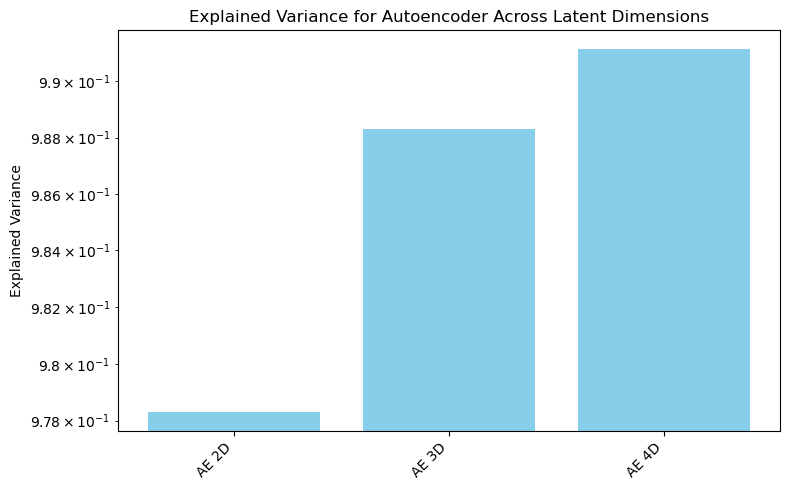

In [17]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------
# 1) Récupération du jeu "val_data"
#    => On veut reconstruire TOUTES les étoiles de la validation
# ---------------------------
# Dans votre code, après:
# train_data, val_data = torch.utils.data.random_split(...)
# val_dataset = AutoencoderDataset(val_data.dataset[val_data.indices])

# On peut directement récupérer le tenseur original du val_data:
val_X = val_data.dataset[val_data.indices]  # shape (N_val, 17)

# Convertir en numpy pour calculer la variance totale plus tard
# ou on fera tout en PyTorch et convertira à la fin:
val_X_np = val_X.numpy()  # shape (N_val, 17)

# Calcul de la "variance totale" sur le jeu de validation
# (On considère .T pour que np.cov(...) attende rowvar=False => colonnes = variables)
cov_matrix = np.cov(val_X_np, rowvar=False)
total_variance = np.trace(cov_matrix)

print(f"Taille du jeu de validation: {val_X_np.shape}, variance totale={total_variance:.4f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_folder = "output_weight"
latent_dims = [2, 3, 4]

explained_variances_ae = {}

# On prépare val_X sur GPU (ou CPU) pour la reconstruction
val_X_tensor = val_X.to(device)

for d in latent_dims:
    model_path = os.path.join(weight_folder, f"best_autoencoder_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"*** Pas de fichier de poids trouvé pour {d}D: {model_path} ***")
        continue

    # Initialiser le même modèle qu’à l'entraînement
    model = Autoencoder(input_dim=17, latent_dim=d).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Reconstruire TOUTES les étoiles de val_data
    with torch.no_grad():
        x_recon_tensor = model(val_X_tensor)  # shape (N_val, 17)

    # Convertir en numpy
    x_recon_np = x_recon_tensor.cpu().numpy()

    # Calcul de la MSE globale sur val_data
    mse_global = np.mean((x_recon_np - val_X_np)**2)

    # Calcul de la variance expliquée
    explained_variance = 1.0 - (mse_global / total_variance)
    explained_variances_ae[d] = explained_variance

    print(f"[{d}D] MSE={mse_global:.6f}, Var_expl={explained_variance:.6f}")

# ---------------------------
# 4) Afficher un diagramme en barres
#    "Explained Variance" pour AE 2D/3D/4D
# ---------------------------
# Préparer les labels sur l'axe X
labels = [f"AE {d}D" for d in latent_dims if d in explained_variances_ae]
ev_values = [explained_variances_ae[d] for d in latent_dims if d in explained_variances_ae]

plt.figure(figsize=(8, 5))
plt.bar(range(len(labels)), ev_values, color='skyblue')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Explained Variance")
plt.yscale("log")  # semilogy()
plt.title("Explained Variance for Autoencoder Across Latent Dimensions")
plt.tight_layout()
plt.show()
